In [1]:
# -------- IMPORTS --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("/mnt/staas/CLICHE/00_DATA/facility_eo_pool_v3.csv")
metrics = ["freq_mean", "dur_mean", "pct75_consecutive", "temporal_coverage"]
print("Shape dataset:", df.shape)
print("\nMissing values per column:")
print(df[metrics].isna().mean())

Shape dataset: (20748, 11)

Missing values per column:
freq_mean            0.649894
dur_mean             0.649894
pct75_consecutive    0.649894
temporal_coverage    0.649894
dtype: float64


In [3]:
# -------------------------------
# 2. BASIC SANITY CHECKS
# -------------------------------
print("\n===== RANGE CHECK =====")
print("freq range:", df.freq_mean.min(), df.freq_mean.max())
print("dur range:", df.dur_mean.min(), df.dur_mean.max())
print("pct75_consecutive range:", df.pct75_consecutive.min(), df.pct75_consecutive.max())
print("temporal_coverage range:", df.temporal_coverage.min(), df.temporal_coverage.max())

# Physical constraints
assert df.freq_mean.dropna().between(0,1).all(), "Frequency outside [0,1]"
assert df.temporal_coverage.dropna().between(0,1).all(), "Coverage outside [0,1]"
assert (df.dur_mean.dropna() >= 0).all(), "Negative duration"
assert (df.pct75_consecutive.dropna() >= 0).all(), "Negative consecutive days"

print("✔ Physical constraints OK")



===== RANGE CHECK =====
freq range: 0.0 0.9861806035041808
dur range: 0.0 356.6766662597656
pct75_consecutive range: 0.0 365.0
temporal_coverage range: 0.8723651476142821 0.9999657148196374
✔ Physical constraints OK


In [4]:
# -------------------------------
# 3. REMOVE ROWS WITH NaNs (for structure analysis only)
# -------------------------------
df_clean = df.dropna(subset=metrics).copy()
print("\nRows usable for structure analysis:", len(df_clean))


Rows usable for structure analysis: 7264


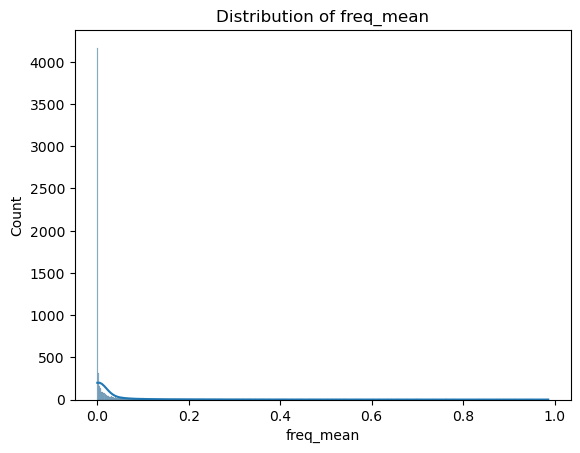

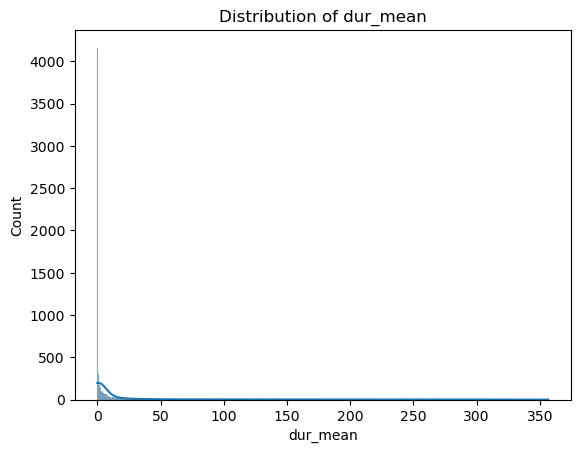

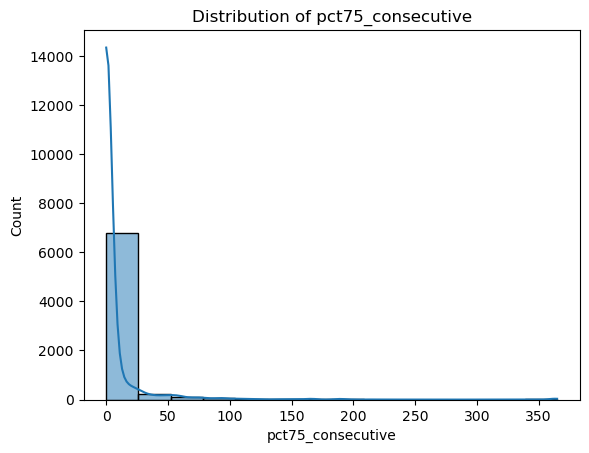

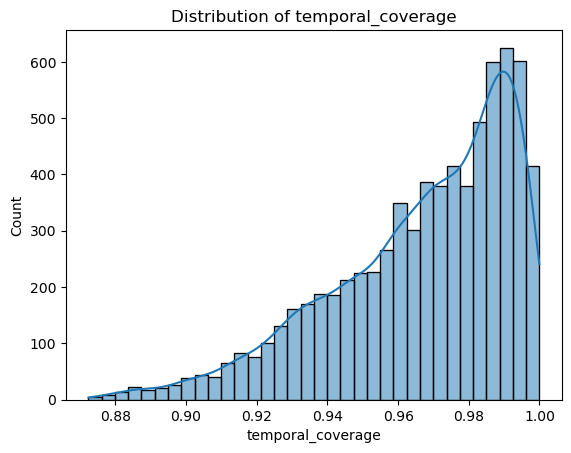

In [5]:
# -------------------------------
# 4. DISTRIBUTION INSPECTION
# -------------------------------
for col in metrics:
    plt.figure()
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [6]:
# Skewness & kurtosis
print("\n===== DISTRIBUTION SHAPE =====")
for col in metrics:
    print(f"{col}: skew={stats.skew(df_clean[col]):.2f}, kurtosis={stats.kurtosis(df_clean[col]):.2f}")



===== DISTRIBUTION SHAPE =====
freq_mean: skew=5.76, kurtosis=39.70
dur_mean: skew=5.87, kurtosis=41.46
pct75_consecutive: skew=8.28, kurtosis=91.75
temporal_coverage: skew=-0.94, kurtosis=0.33



===== CORRELATION (Pearson) =====
                   freq_mean  dur_mean  pct75_consecutive  temporal_coverage
freq_mean           1.000000  0.998215           0.916056           0.175236
dur_mean            0.998215  1.000000           0.926562           0.176102
pct75_consecutive   0.916056  0.926562           1.000000           0.150806
temporal_coverage   0.175236  0.176102           0.150806           1.000000

===== CORRELATION (Spearman) =====
                   freq_mean  dur_mean  pct75_consecutive  temporal_coverage
freq_mean           1.000000  0.999942           0.727615           0.201253
dur_mean            0.999942  1.000000           0.727776           0.203042
pct75_consecutive   0.727615  0.727776           1.000000           0.187324
temporal_coverage   0.201253  0.203042           0.187324           1.000000


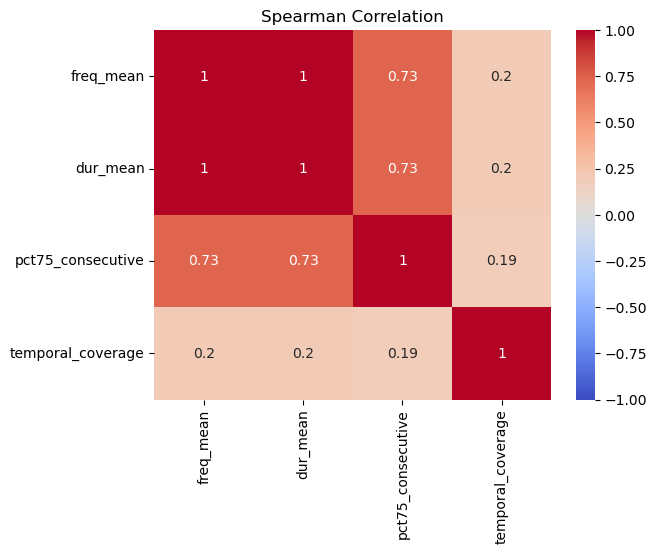

In [7]:
# -------------------------------
# 5. CORRELATION ANALYSIS
# -------------------------------
print("\n===== CORRELATION (Pearson) =====")
corr_pearson = df_clean[metrics].corr(method="pearson")
print(corr_pearson)

print("\n===== CORRELATION (Spearman) =====")
corr_spearman = df_clean[metrics].corr(method="spearman")
print(corr_spearman)

plt.figure()
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Correlation")
plt.show()


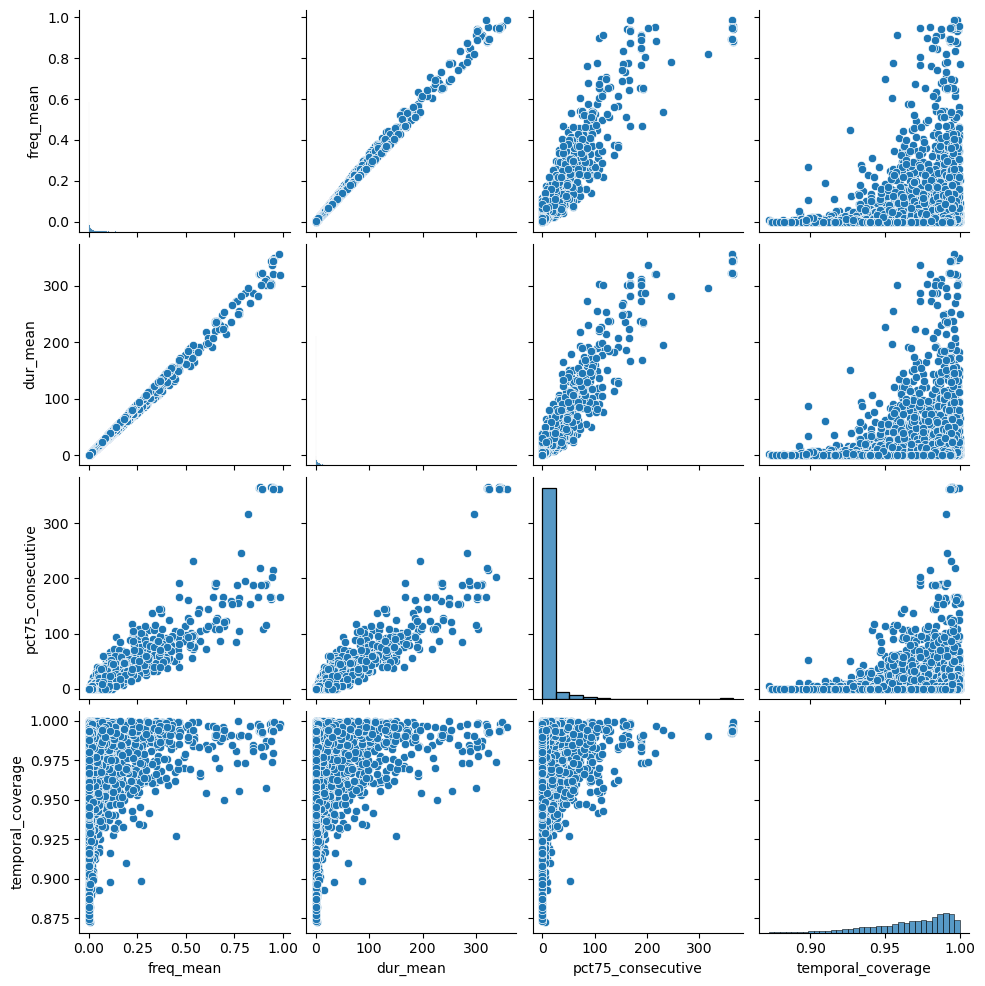

In [8]:
# -------------------------------
# 6. SCATTERPLOTS (DEPENDENCE STRUCTURE)
# -------------------------------
sns.pairplot(df_clean[metrics])
plt.show()

In [9]:
# -------------------------------
# 7. VIF (REDUNDANCY TEST)
# -------------------------------
X = df_clean[metrics].copy()
X["intercept"] = 1

vif_data = pd.DataFrame()
vif_data["Variable"] = metrics
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(len(metrics))
]

print("\n===== VIF =====")
print(vif_data)


===== VIF =====
            Variable         VIF
0          freq_mean  332.010926
1           dur_mean  377.750180
2  pct75_consecutive    8.380514
3  temporal_coverage    1.033779



===== PCA EXPLAINED VARIANCE =====
[7.34453390e-01 2.39217040e-01 2.59765452e-02 3.53024640e-04]


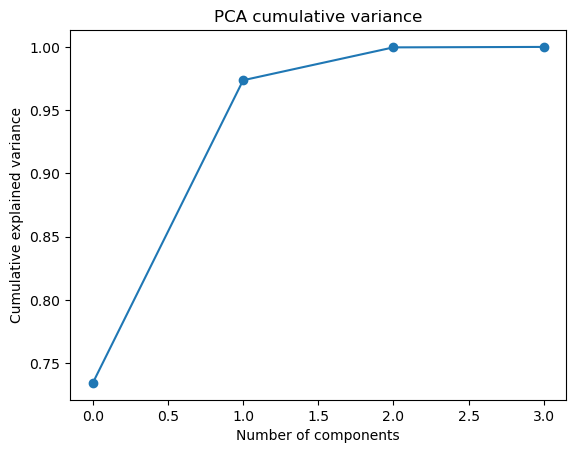


PCA loadings:
                        PC1       PC2       PC3       PC4
freq_mean          0.575503 -0.078491 -0.443446 -0.682636
dur_mean           0.577549 -0.078691 -0.358808  0.729041
pct75_consecutive  0.559735 -0.099705  0.821127 -0.050057
temporal_coverage  0.148089  0.988790  0.019042 -0.001216


In [10]:
# -------------------------------
# 8. PCA (STRUCTURAL DIMENSION)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[metrics])

pca = PCA()
pca.fit(X_scaled)

print("\n===== PCA EXPLAINED VARIANCE =====")
print(pca.explained_variance_ratio_)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative variance")
plt.show()

print("\nPCA loadings:")
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(metrics))],
    index=metrics
)
print(loadings)

In [11]:
# -------------------------------
# 9. EXTREME COMBINATIONS CHECK
# -------------------------------

print("\n===== LOGICAL CONSISTENCY CHECK =====")

# Example impossible case:
# High duration but zero frequency
inconsistent = df_clean[
    (df_clean["dur_mean"] > df_clean["dur_mean"].quantile(0.9)) &
    (df_clean["freq_mean"] < df_clean["freq_mean"].quantile(0.1))
]

print("Potentially inconsistent cases:", len(inconsistent))


===== LOGICAL CONSISTENCY CHECK =====
Potentially inconsistent cases: 0


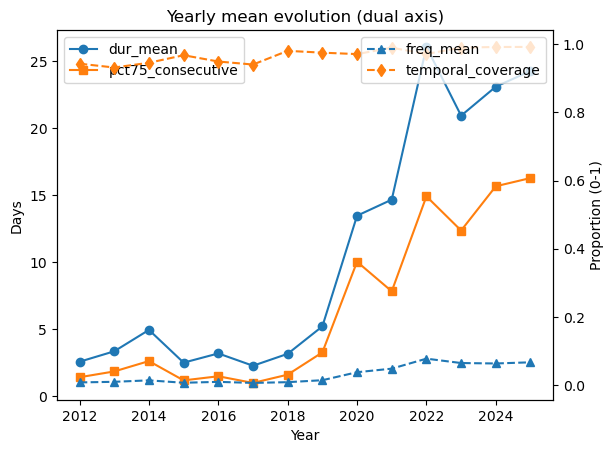

In [13]:
# -------------------------------
# 10. STATIONARITY OVER YEARS (Dual axis)
# -------------------------------

year_means = df_clean.groupby("year")[metrics].mean()

fig, ax1 = plt.subplots()

# Eje izquierdo: duración y racha
ax1.plot(year_means.index, year_means["dur_mean"], marker="o", label="dur_mean")
ax1.plot(year_means.index, year_means["pct75_consecutive"], marker="s", label="pct75_consecutive")
ax1.set_ylabel("Days")
ax1.set_xlabel("Year")
ax1.legend(loc="upper left")

# Eje derecho: frecuencia y cobertura
ax2 = ax1.twinx()
ax2.plot(year_means.index, year_means["freq_mean"], marker="^", linestyle="--", label="freq_mean")
ax2.plot(year_means.index, year_means["temporal_coverage"], marker="d", linestyle="--", label="temporal_coverage")
ax2.set_ylabel("Proportion (0-1)")

ax2.legend(loc="upper right")

plt.title("Yearly mean evolution (dual axis)")
plt.show()